In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rahmanashfakur/onlineretail/OnlineRetail.csv


In [5]:
kaggle_path = '/kaggle/input/datasets/rahmanashfakur/onlineretail/OnlineRetail.csv'
local_path = 'OnlineRetail.csv'
path = kaggle_path if os.path.exists(kaggle_path) else local_path

df = pd.read_csv(path, encoding='unicode_escape')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541909, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Data Cleaning
RFM calculation er age dataset e kichu shomossha clean kore newa dorkar:
- `CustomerID` null emon row (customer chara RFM banano jabe na)
- Cancelled invoice (InvoiceNo "C" diye shuru)
- Negative Quantity (return/cancellation)
- `UnitPrice` = 0 emon row
- Duplicate row

In [9]:
before = df.shape[0]

df = df.dropna(subset=['CustomerID'])                         # null CustomerID bad
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]     # cancelled invoice bad
df = df[df['Quantity'] > 0]                                    # negative/return quantity bad
df = df[df['UnitPrice'] > 0]                                   # zero price bad
df = df.drop_duplicates()                                      # duplicate row bad
df.reset_index(drop=True, inplace=True)

after = df.shape[0]
print(f"Before cleaning: {before} rows")
print(f"After cleaning: {after} rows")
print(f"Removed: {before-after} rows ({(before-after)/before*100:.1f}%)")

Before cleaning: 541909 rows
After cleaning: 392692 rows
Removed: 149217 rows (27.5%)


In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

## RFM Feature Engineering
- **Recency**: shesh purchase koto din age hoyeche
- **Frequency**: koto ti alada invoice/order koreche
- **Monetary**: total koto taka khoroch koreche

In [11]:
currentDate = df['InvoiceDate'].max() + pd.Timedelta(days=1)  # dataset er last transaction er 1 din por ke reference dhora holo
currentDate

Timestamp('2011-12-10 12:50:00')

In [12]:
# Recency
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (currentDate - recency['InvoiceDate']).dt.days
recency = recency[['CustomerID', 'Recency']]
recency.head()

,CustomerID,Recency
0,12346.0,326
1,12347.0,2
2,12348.0,75
3,12349.0,19
4,12350.0,310


In [13]:
# Frequency
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency.columns = ['CustomerID', 'Frequency']
frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [14]:
# Monetary
df['total'] = df['Quantity'] * df['UnitPrice']
monetary = df.groupby('CustomerID')['total'].sum().reset_index()
monetary.columns = ['CustomerID', 'Monetary']
monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [15]:
RFM = recency.merge(frequency, on='CustomerID').merge(monetary, on='CustomerID')
RFM.set_index('CustomerID', inplace=True)
RFM

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [16]:
RFM.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## Feature Scaling
KMeans distance-based algorithm, tai Recency/Frequency/Monetary ke same scale e ante hobe,
noile Monetary (jar range onek boro) baki dutake dominate kore felbe.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(RFM)
scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

## Optimal K Nirbachon (Elbow Method)

In [18]:
from sklearn.cluster import KMeans

k_range = range(1, 10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    sse.append(km.inertia_)

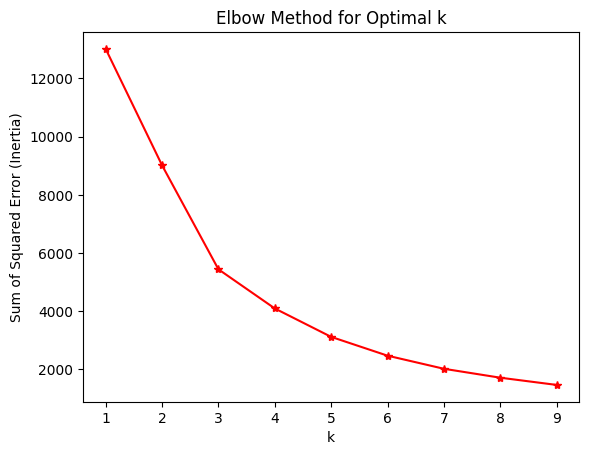

In [19]:
import matplotlib.pyplot as plt

plt.plot(list(k_range), sse, 'r-*')
plt.xlabel('k')
plt.ylabel('Sum of Squared Error (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

Elbow curve dekhe bojha jacche **k=3** er kachakachi SSE kamar har hothat kome jacche
(elbow point), tai k=3 ke optimal cluster shongkha hisebe newa holo.

## KMeans Clustering

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(scaled)

RFM['Clusters'] = kmeans.labels_
RFM.head()

,Recency,Frequency,Monetary,Clusters
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0


## Clustering Quality Check
Eta unsupervised learning, tai accuracy/precision/recall/F1 (egulo classification er metric)
kaj korbe na — ground truth label nai. Er bodole clustering-specific metric byabohar kora hoy:

- **Silhouette Score**: -1 theke 1 er modhye, 1 er kache hole cluster gulo valo bhabe alada
- **Davies-Bouldin Index**: 0 er kache hole valo (cluster gulo kom overlap kore)

In [21]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(scaled, kmeans.labels_)
db_score = davies_bouldin_score(scaled, kmeans.labels_)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")

Silhouette Score: 0.594
Davies-Bouldin Index: 0.710


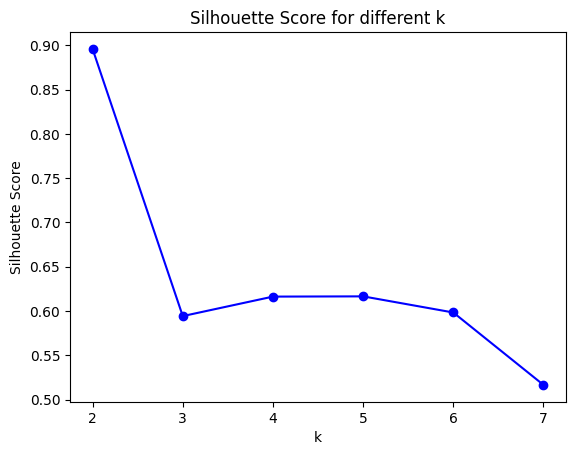

k=2: silhouette=0.896
k=3: silhouette=0.594
k=4: silhouette=0.616
k=5: silhouette=0.617
k=6: silhouette=0.598
k=7: silhouette=0.517


In [22]:
# Different k er jonno silhouette score compare kora (optional validation, elbow method ke support kore)
sil_scores = []
k_range2 = range(2, 8)
for k in k_range2:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled)
    sil_scores.append(silhouette_score(scaled, labels))

plt.plot(list(k_range2), sil_scores, 'b-o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for different k')
plt.show()

for k, s in zip(k_range2, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

## Cluster Labeling
Cluster number (0,1,2) nijei kono meaning bohon kore na — tai `final` table theke Monetary
onujayi dynamically rank kore label boshano hocche: shobcheye beshi Monetary jar cluster e,
seta **Diamond**, tarpor **Gold**, tarpor **Silver**.

In [23]:
final = RFM.groupby('Clusters')[['Recency', 'Frequency', 'Monetary']].mean()
final

,Recency,Frequency,Monetary
Clusters,,,
0,247.106285,1.582255,629.663689
1,41.454180,4.672755,1849.670202
2,6.038462,66.423077,85826.078077


In [24]:
cluster_rank = final.sort_values('Monetary', ascending=False).index.tolist()
label_map = {cluster_rank[0]: 'Diamond', cluster_rank[1]: 'Gold', cluster_rank[2]: 'Silver'}
print("Cluster -> Group mapping:", label_map)

RFM['group'] = RFM['Clusters'].map(label_map)
RFM.head()

Cluster -> Group mapping: {2: 'Diamond', 1: 'Gold', 0: 'Silver'}


,Recency,Frequency,Monetary,Clusters,group
CustomerID,,,,,
12346.0,326,1,77183.60,0,Silver
12347.0,2,7,4310.00,1,Gold
12348.0,75,4,1797.24,1,Gold
12349.0,19,1,1757.55,1,Gold
12350.0,310,1,334.40,0,Silver


In [25]:
result = RFM['group'].value_counts()
result

group
Gold       3230
Silver     1082
Diamond      26
Name: count, dtype: int64

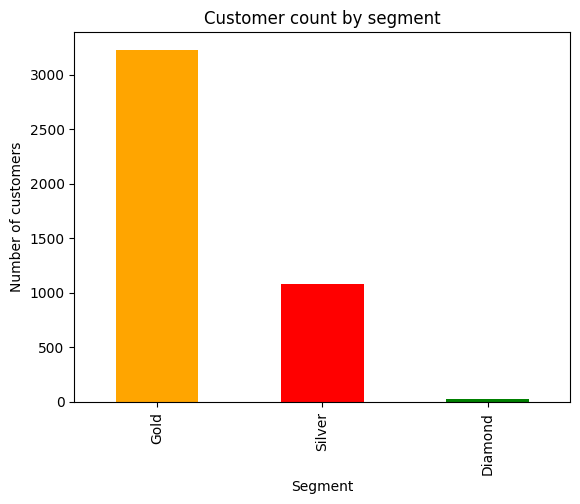

In [26]:
result.plot(kind='bar', color=['Orange','Red','Green'])
plt.title('Customer count by segment')
plt.ylabel('Number of customers')
plt.xlabel('Segment')
plt.show()

## RFM Distribution (Visualization)

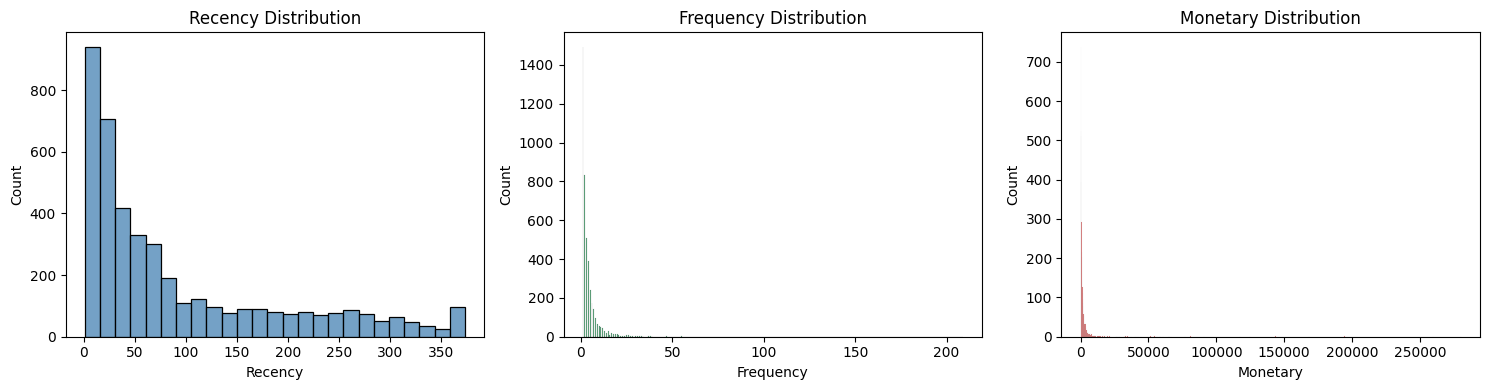

In [27]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(RFM['Recency'], ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution')
sns.histplot(RFM['Frequency'], ax=axes[1], color='seagreen')
axes[1].set_title('Frequency Distribution')
sns.histplot(RFM['Monetary'], ax=axes[2], color='indianred')
axes[2].set_title('Monetary Distribution')
plt.tight_layout()
plt.show()

In [28]:
# Sob cheye kom active (Silver) group er modhye shobcheye kom Monetary customer khuje ber kora
silver_customers = RFM[RFM['group'] == 'Silver']
silver_customers[silver_customers['Monetary'] == silver_customers['Monetary'].min()]

,Recency,Frequency,Monetary,Clusters,group
CustomerID,,,,,
16738.0,298,1,3.75,0,Silver


In [29]:
print("Total unique customers:", RFM.shape[0])
print()
print("Segment wise customer count:")
print(result)
print()
print("Segment wise average Recency/Frequency/Monetary:")
print(final.rename(index=label_map))
print()
print(f"Silhouette Score (k=3): {sil_score:.3f}")
print(f"Davies-Bouldin Index (k=3): {db_score:.3f}")

Total unique customers: 4338

Segment wise customer count:
group
Gold       3230
Silver     1082
Diamond      26
Name: count, dtype: int64

Segment wise average Recency/Frequency/Monetary:
             Recency  Frequency      Monetary
Clusters                                     
Silver    247.106285   1.582255    629.663689
Gold       41.454180   4.672755   1849.670202
Diamond     6.038462  66.423077  85826.078077

Silhouette Score (k=3): 0.594
Davies-Bouldin Index (k=3): 0.710


## Conclusion

RFM (Recency, Frequency, Monetary) analysis o KMeans clustering byabohar kore customer der
tinta segment e bhag kora hoyeche:

- **Diamond**: Shobcheye beshi Monetary o Frequency, Recency shobcheye kom (mane recent purchase
  korechen) — eder ei shobcheye valuable customer, retention e focus deya uchit (loyalty program,
  exclusive offer).
- **Gold**: Moderate activity — eder purchase frequency baranor jonno targeted promotion deya jete pare.
- **Silver**: Kom active, Recency beshi (onek din age last purchase korechen) — eder win-back/re-engagement
  campaign (discount, reminder email) proyojon, noile churn er ashonka beshi.

**Model validation**: Eta unsupervised clustering bole accuracy/precision/recall/F1 applicable na —
er bodole Silhouette Score o Davies-Bouldin Index diye cluster quality validate kora hoyeche,
ebong `random_state=42` fix kora tay result reproducible.